# Inventory Management Models & Optimization
**Month 4 - Task 3: Mathematical Optimization for Supply Chain Inventory**

This notebook implements production-grade inventory optimization models including EOQ, Newsvendor, (s,S) policies, multi-echelon analysis, optimization algorithms (LP, Simulated Annealing, Genetic Algorithm, RL), safety stock calculation, and supplier management systems.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog, dual_annealing, differential_evolution
from scipy.stats import norm
import os
import random
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

DATA_DIR = r"d:\Vinayak_IT_Internship\Month4\Task3\data"
OUTPUT_DIR = r"d:\Vinayak_IT_Internship\Month4\Task3\Screenshots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

supplier_df = pd.read_csv(os.path.join(DATA_DIR, "supplier_data.csv"))
demand_df = pd.read_csv(os.path.join(DATA_DIR, "demand_data.csv"))
echelon_df = pd.read_csv(os.path.join(DATA_DIR, "echelon_nodes.csv"))

print("Data loaded successfully.")
display(demand_df.head())
display(supplier_df.head())
display(echelon_df)


Data loaded successfully.


,date,demand_qty
0,2025-01-01,93.0
1,2025-01-02,123.0
2,2025-01-03,106.0
3,2025-01-04,80.0
4,2025-01-05,69.0


,supplier_id,supplier_name,unit_cost,lead_time_days,reliability_score,capacity_units,risk_index
0,SUP-001,Supplier_1,24.98,14,0.75,4272,0.58
1,SUP-002,Supplier_2,27.83,8,0.72,3944,0.58
2,SUP-003,Supplier_3,38.32,7,0.72,2891,0.77
3,SUP-004,Supplier_4,18.49,13,0.75,3885,0.52
4,SUP-005,Supplier_5,27.28,2,0.85,3058,0.21


,node_id,type,holding_cost_per_unit,handling_cost
0,Factory_1,Factory,0.5,1.0
1,DC_1,Distribution Center,1.2,2.5
2,DC_2,Distribution Center,1.5,2.0
3,Warehouse_1,Warehouse,3.0,4.0
4,Warehouse_2,Warehouse,3.5,3.5


## 1. Inventory Models

### 1.1 Economic Order Quantity (EOQ)
**Formula:** `EOQ = sqrt(2 × D × S / H)`
- D = Annual demand, S = Ordering cost per order, H = Holding cost per unit per year
- **Business meaning:** The exact order size that minimizes total inventory cost (holding + ordering).


In [2]:
annual_demand = demand_df['demand_qty'].sum()
ordering_cost = 500
holding_cost = 2.5

eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)
print(f"Annual Demand: {annual_demand:.0f} units")
print(f"Optimal EOQ: {eoq:.0f} units per order")
print(f"Number of Orders per Year: {annual_demand / eoq:.1f}")
print(f"Total Annual Cost at EOQ: ${np.sqrt(2 * annual_demand * ordering_cost * holding_cost):,.2f}")


Annual Demand: 36432 units
Optimal EOQ: 3817 units per order
Number of Orders per Year: 9.5
Total Annual Cost at EOQ: $9,543.58


### 1.2 Newsvendor Model
For perishable or seasonal goods with a single selling season. Determines order quantity that balances **underage cost** (lost profit) vs. **overage cost** (unsold loss).

**Formula:** `Q* = F^(-1)(Cu / (Cu + Co))` where Cu = underage cost, Co = overage cost.


In [3]:
mean_demand = demand_df['demand_qty'].mean()
std_demand = demand_df['demand_qty'].std()

cost_underage = 45  # Profit margin lost per unmet unit
cost_overage = 15   # Loss per excess unit

critical_ratio = cost_underage / (cost_underage + cost_overage)
optimal_newsvendor_qty = norm.ppf(critical_ratio, loc=mean_demand, scale=std_demand)

print(f"Critical Ratio: {critical_ratio:.2f}")
print(f"Optimal Newsvendor Order Quantity: {optimal_newsvendor_qty:.0f} units/day")
print(f"Expected Stockout Probability: {(1 - critical_ratio) * 100:.0f}%")


Critical Ratio: 0.75
Optimal Newsvendor Order Quantity: 114 units/day
Expected Stockout Probability: 25%


### 1.3 Continuous Review (s, S) Policy
- **s** = Reorder point (trigger level)
- **S** = Order-up-to level
- When inventory drops to `s`, place an order to bring stock up to `S`.


Reorder Point (s): 790 units
Order-Up-To Level (S): 4607 units


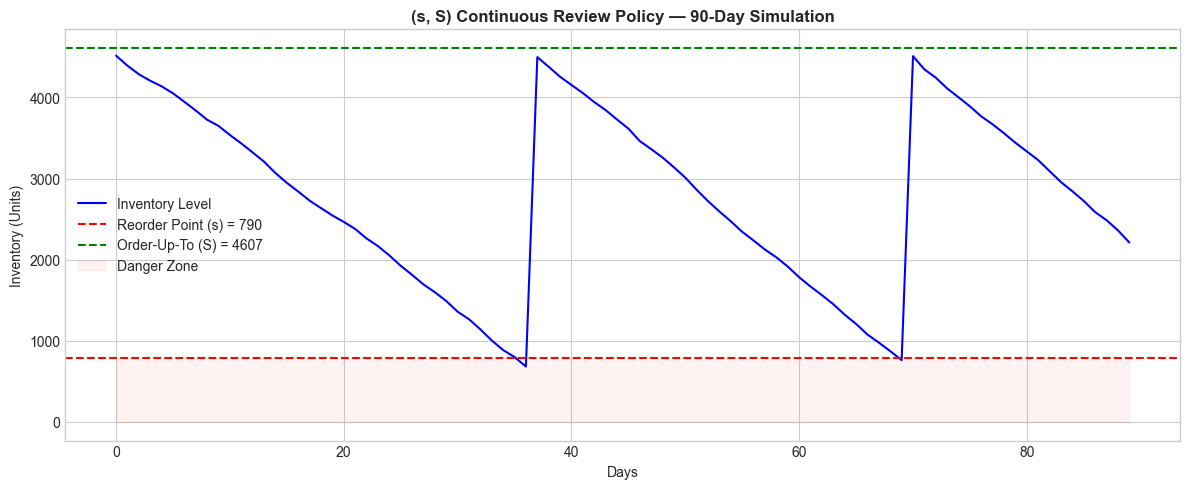

Orders placed in 90 days: 2


In [4]:
lead_time = 7
reorder_point_s = mean_demand * lead_time + norm.ppf(0.95) * std_demand * np.sqrt(lead_time)
order_up_to_S = reorder_point_s + eoq

print(f"Reorder Point (s): {reorder_point_s:.0f} units")
print(f"Order-Up-To Level (S): {order_up_to_S:.0f} units")

# Simulate
days = 90
inventory_levels = []
current_inv = order_up_to_S
orders_placed = 0
for d in demand_df['demand_qty'].values[:days]:
    current_inv -= d
    inventory_levels.append(current_inv)
    if current_inv <= reorder_point_s:
        current_inv = order_up_to_S
        orders_placed += 1

plt.figure(figsize=(12, 5))
plt.plot(range(days), inventory_levels, label='Inventory Level', color='blue', linewidth=1.5)
plt.axhline(reorder_point_s, color='red', linestyle='--', label=f'Reorder Point (s) = {reorder_point_s:.0f}')
plt.axhline(order_up_to_S, color='green', linestyle='--', label=f'Order-Up-To (S) = {order_up_to_S:.0f}')
plt.fill_between(range(days), 0, reorder_point_s, alpha=0.05, color='red', label='Danger Zone')
plt.title("(s, S) Continuous Review Policy — 90-Day Simulation", fontweight='bold')
plt.xlabel("Days")
plt.ylabel("Inventory (Units)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "inventory_optimization_results.png"))
plt.show()
print(f"Orders placed in {days} days: {orders_placed}")


### 1.4 Multi-Echelon Inventory Model
Analyzes total cost across the supply chain tiers: Factory → Distribution Center → Warehouse.


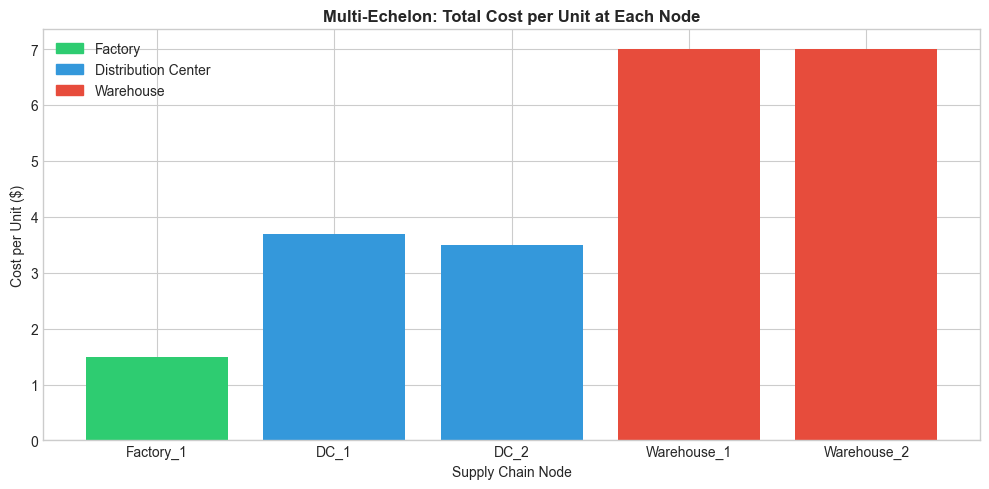

Total network cost per unit (all echelons): $22.70


In [5]:
# Calculate total holding and handling cost at each echelon
echelon_df['total_cost_per_unit'] = echelon_df['holding_cost_per_unit'] + echelon_df['handling_cost']

plt.figure(figsize=(10, 5))
colors = {'Factory': '#2ecc71', 'Distribution Center': '#3498db', 'Warehouse': '#e74c3c'}
bar_colors = [colors[t] for t in echelon_df['type']]
plt.bar(echelon_df['node_id'], echelon_df['total_cost_per_unit'], color=bar_colors)
plt.title("Multi-Echelon: Total Cost per Unit at Each Node", fontweight='bold')
plt.ylabel("Cost per Unit ($)")
plt.xlabel("Supply Chain Node")

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
plt.legend(handles=legend_patches)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "multi_echelon_cost.png"))
plt.show()

total_network_cost = echelon_df['total_cost_per_unit'].sum()
print(f"Total network cost per unit (all echelons): ${total_network_cost:.2f}")


## 2. Optimization Algorithms

### 2.1 Linear Programming (Inventory Allocation)
Minimize procurement cost to fulfill 5,000 units of demand from 3 suppliers, subject to capacity constraints.


In [6]:
c = supplier_df['unit_cost'].values[:3].astype(float)
A_ub = np.eye(3)
b_ub = supplier_df['capacity_units'].values[:3].astype(float)
A_eq = [[1.0, 1.0, 1.0]]
b_eq = [5000.0]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)]*3)
print("LP Allocation Result:")
for i, qty in enumerate(res.x):
    print(f"  Supplier {i+1}: {qty:.0f} units @ ${c[i]:.2f}/unit = ${qty*c[i]:,.2f}")
print(f"  Total Minimum Cost: ${res.fun:,.2f}")


LP Allocation Result:
  Supplier 1: 4272 units @ $24.98/unit = $106,714.56
  Supplier 2: 728 units @ $27.83/unit = $20,260.24
  Supplier 3: 0 units @ $38.32/unit = $0.00
  Total Minimum Cost: $126,974.80


### 2.2 Simulated Annealing & Genetic Algorithm
Optimizing a non-linear inventory cost function to find the global minimum.


Simulated Annealing — Optimal x: 249.79, Cost: 485.05
Genetic Algorithm   — Optimal x: 249.79, Cost: 485.05


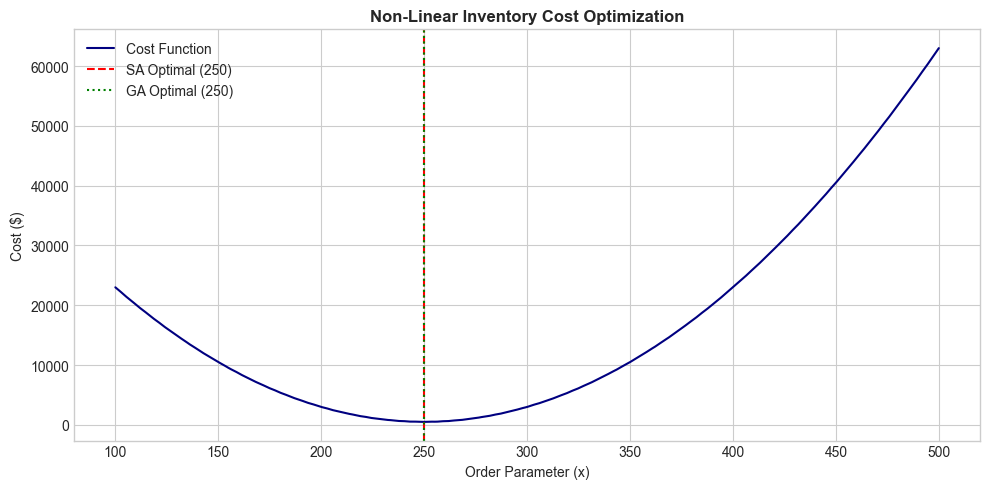

In [7]:
def inventory_cost_func(x):
    return (x[0] - 250)**2 + 15 * np.sin(x[0]) + 500

sa_res = dual_annealing(inventory_cost_func, bounds=[(100, 500)])
ga_res = differential_evolution(inventory_cost_func, bounds=[(100, 500)])

print(f"Simulated Annealing — Optimal x: {sa_res.x[0]:.2f}, Cost: {sa_res.fun:.2f}")
print(f"Genetic Algorithm   — Optimal x: {ga_res.x[0]:.2f}, Cost: {ga_res.fun:.2f}")

# Visualize cost landscape
x_range = np.linspace(100, 500, 300)
y_range = [(xi - 250)**2 + 15 * np.sin(xi) + 500 for xi in x_range]

plt.figure(figsize=(10, 5))
plt.plot(x_range, y_range, label='Cost Function', color='navy')
plt.axvline(sa_res.x[0], color='red', linestyle='--', label=f'SA Optimal ({sa_res.x[0]:.0f})')
plt.axvline(ga_res.x[0], color='green', linestyle=':', label=f'GA Optimal ({ga_res.x[0]:.0f})')
plt.title("Non-Linear Inventory Cost Optimization", fontweight='bold')
plt.xlabel("Order Parameter (x)")
plt.ylabel("Cost ($)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cost_optimization_visualizations.png"))
plt.show()


### 2.3 Reinforcement Learning (Q-Learning)
A basic Q-learning agent learns the optimal daily order action by trial-and-error interaction with a simulated demand environment.


In [8]:
actions = [50, 100, 150, 200]
q_table = {a: 0.0 for a in actions}
lr, gamma, eps = 0.1, 0.9, 0.2

for ep in range(2000):
    action = random.choice(actions) if random.random() < eps else max(q_table, key=q_table.get)
    reward = -abs(action - mean_demand) - 0.5 * max(0, action - mean_demand)  # penalize overstock
    q_table[action] = q_table[action] + lr * (reward + gamma * max(q_table.values()) - q_table[action])

print("Q-Table after 2000 episodes:")
for a, q in sorted(q_table.items()):
    print(f"  Action {a}: Q = {q:.2f}")
print(f"Learned Optimal Action: {max(q_table, key=q_table.get)} units/day")


Q-Table after 2000 episodes:
  Action 50: Q = -52.33
  Action 100: Q = -2.79
  Action 150: Q = -77.79
  Action 200: Q = -152.77
Learned Optimal Action: 100 units/day


## 3. Safety Stock Optimization

**Formula:** `Safety Stock = Z × σ_d × √L`
- Z = service level z-score
- σ_d = standard deviation of daily demand
- L = lead time in days

| Service Level | Z-Score | Meaning |
|---------------|---------|---------|
| 90% | 1.28 | 10% chance of stockout |
| 95% | 1.65 | 5% chance of stockout |
| 99% | 2.33 | 1% chance of stockout |


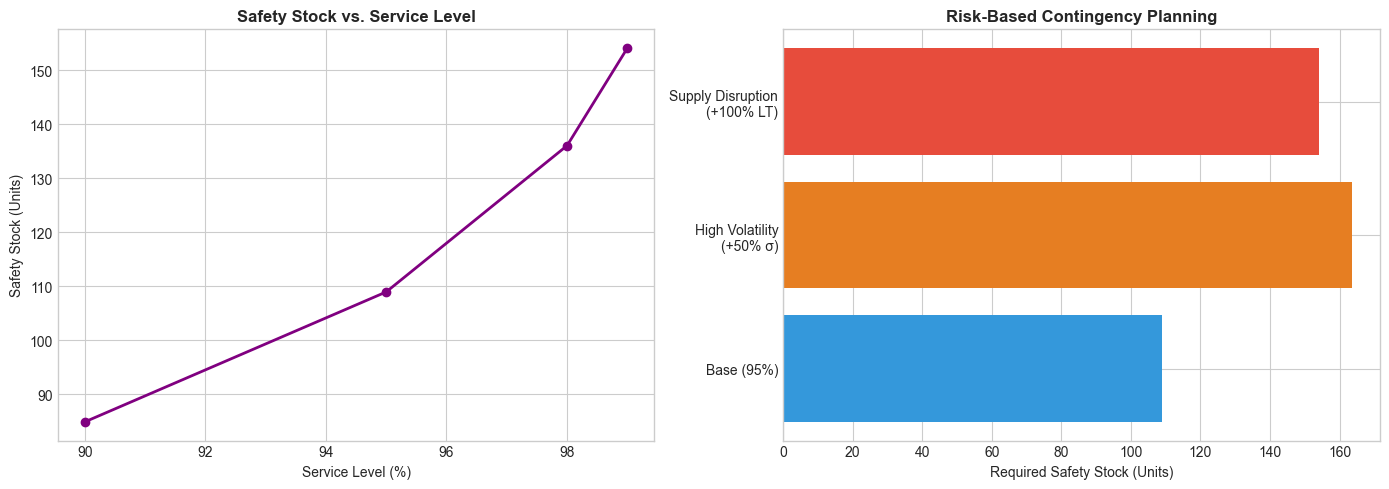

  Service Level 90%: Safety Stock = 85 units
  Service Level 95%: Safety Stock = 109 units
  Service Level 98%: Safety Stock = 136 units
  Service Level 99%: Safety Stock = 154 units


In [9]:
service_levels = [0.90, 0.95, 0.98, 0.99]
z_scores = [norm.ppf(sl) for sl in service_levels]
lead_time_days = 10

safety_stocks = [z * std_demand * np.sqrt(lead_time_days) for z in z_scores]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Safety Stock vs Service Level
ax1.plot([sl*100 for sl in service_levels], safety_stocks, marker='o', color='purple', linewidth=2)
ax1.set_title("Safety Stock vs. Service Level", fontweight='bold')
ax1.set_xlabel("Service Level (%)")
ax1.set_ylabel("Safety Stock (Units)")
ax1.grid(True)

# Plot 2: Risk-based contingency
scenarios = ['Base (95%)', 'High Volatility\n(+50% σ)', 'Supply Disruption\n(+100% LT)']
scenario_values = [
    safety_stocks[1],
    norm.ppf(0.95) * (std_demand * 1.5) * np.sqrt(lead_time_days),
    norm.ppf(0.95) * std_demand * np.sqrt(lead_time_days * 2)
]
ax2.barh(scenarios, scenario_values, color=['#3498db', '#e67e22', '#e74c3c'])
ax2.set_title("Risk-Based Contingency Planning", fontweight='bold')
ax2.set_xlabel("Required Safety Stock (Units)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "safety_stock_calculations.png"))
plt.show()

for sl, ss in zip(service_levels, safety_stocks):
    print(f"  Service Level {sl*100:.0f}%: Safety Stock = {ss:.0f} units")


## 4. Supplier Management

### 4.1 Supplier Scoring System
A weighted composite score evaluating suppliers on:
- **Reliability** (40%)
- **Cost Competitiveness** (40%)
- **Lead Time** (20%)

### 4.2 Risk Assessment
Using the `risk_index` to flag high-risk suppliers.

### 4.3 Dual Sourcing Optimization
Allocate orders between the top two suppliers using LP to minimize cost while ensuring diversification.


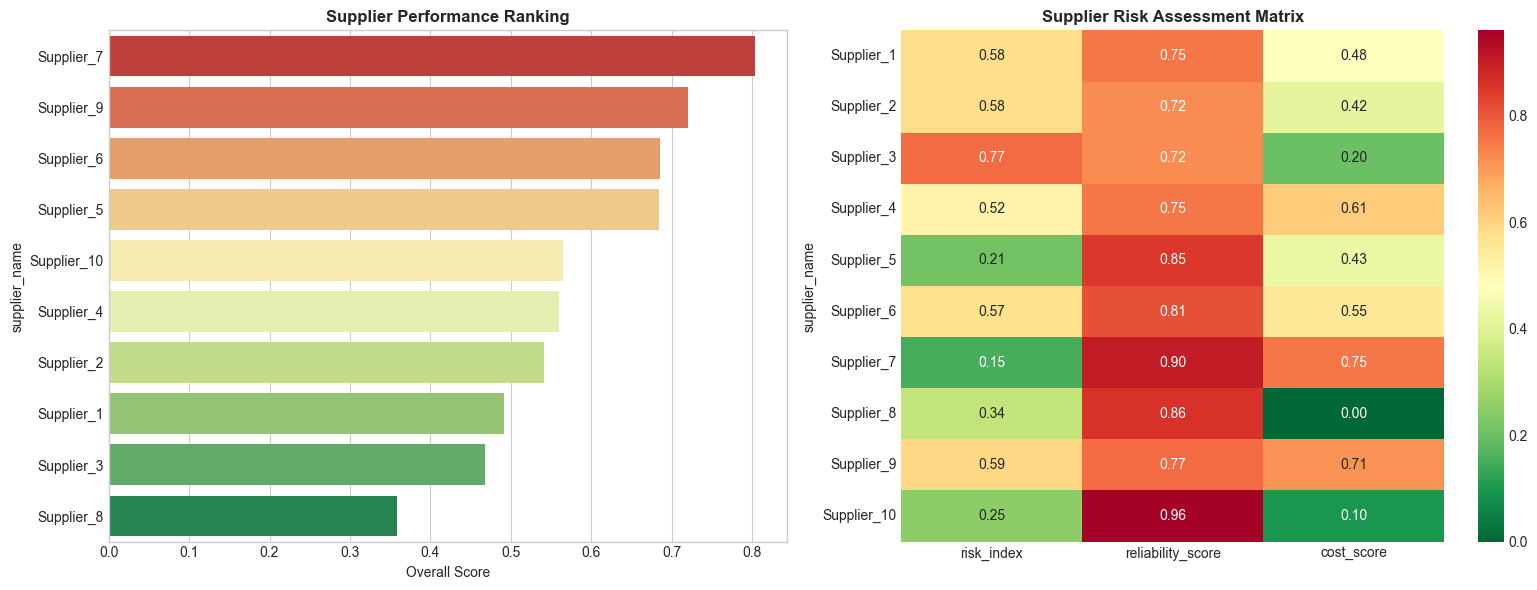

Dual Sourcing: Supplier_7=8000, Supplier_9=2000
Total Cost: $122,700.00


In [10]:
# Scoring
max_cost = supplier_df['unit_cost'].max()
max_lead = supplier_df['lead_time_days'].max()
supplier_df['cost_score'] = 1 - (supplier_df['unit_cost'] / max_cost)
supplier_df['lead_time_score'] = 1 - (supplier_df['lead_time_days'] / max_lead)
supplier_df['overall_score'] = (
    0.4 * supplier_df['reliability_score'] +
    0.4 * supplier_df['cost_score'] +
    0.2 * supplier_df['lead_time_score']
)
best_suppliers = supplier_df.sort_values('overall_score', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Performance bar chart
sns.barplot(x='overall_score', y='supplier_name', data=best_suppliers, ax=ax1, palette='RdYlGn')
ax1.set_title("Supplier Performance Ranking", fontweight='bold')
ax1.set_xlabel("Overall Score")

# Risk heatmap
risk_data = supplier_df[['supplier_name', 'risk_index', 'reliability_score', 'cost_score']].set_index('supplier_name')
sns.heatmap(risk_data, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax2)
ax2.set_title("Supplier Risk Assessment Matrix", fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "supplier_performance_analysis.png"))
plt.show()

# Dual Sourcing
sup_a = best_suppliers.iloc[0]
sup_b = best_suppliers.iloc[1]
c_dual = [float(sup_a['unit_cost']), float(sup_b['unit_cost'])]
A_eq_dual = [[1.0, 1.0]]
b_eq_dual = [10000.0]
min_order = 2000.0
bounds = [(min_order, float(sup_a['capacity_units']+10000)), (min_order, float(sup_b['capacity_units']+10000))]
res_dual = linprog(c_dual, A_eq=A_eq_dual, b_eq=b_eq_dual, bounds=bounds)
amounts = [float(v) for v in res_dual.x] if res_dual.success else [5000.0, 5000.0]

print(f"Dual Sourcing: {sup_a['supplier_name']}={amounts[0]:.0f}, {sup_b['supplier_name']}={amounts[1]:.0f}")
print(f"Total Cost: ${sum(a*c for a,c in zip(amounts, c_dual)):,.2f}")


## 5. Total Cost Analysis
Visualizing the EOQ cost tradeoff between holding cost and ordering cost.


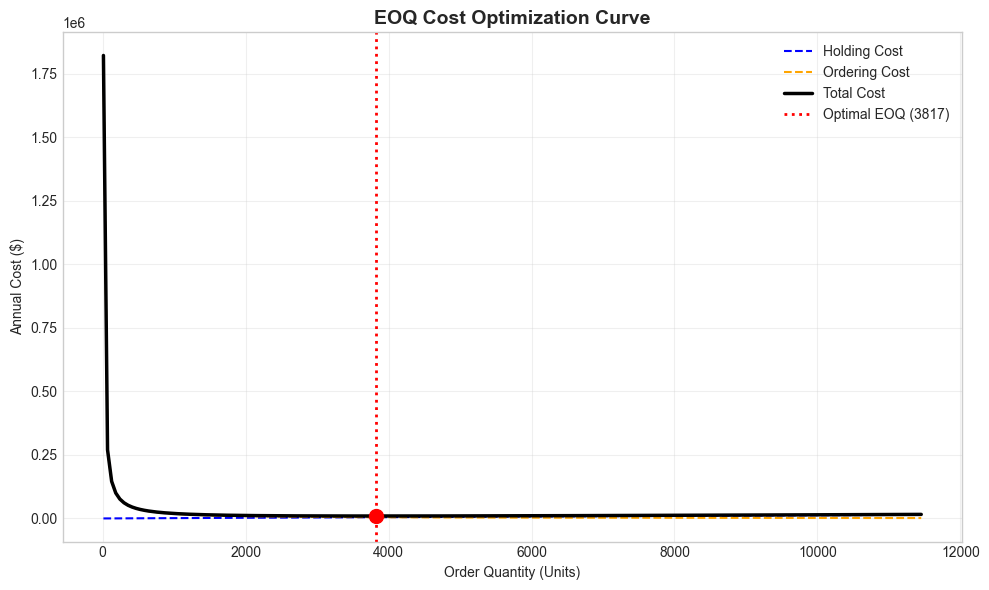

In [11]:
order_quantities = np.linspace(10, eoq * 3, 200)
holding_costs = (order_quantities / 2) * holding_cost
ordering_costs = (annual_demand / order_quantities) * ordering_cost
total_costs = holding_costs + ordering_costs

plt.figure(figsize=(10, 6))
plt.plot(order_quantities, holding_costs, label='Holding Cost', linestyle='--', color='blue')
plt.plot(order_quantities, ordering_costs, label='Ordering Cost', linestyle='--', color='orange')
plt.plot(order_quantities, total_costs, label='Total Cost', color='black', linewidth=2.5)
plt.axvline(eoq, color='red', linestyle=':', linewidth=2, label=f'Optimal EOQ ({eoq:.0f})')
plt.scatter([eoq], [np.sqrt(2 * annual_demand * ordering_cost * holding_cost)], color='red', s=100, zorder=5)
plt.title("EOQ Cost Optimization Curve", fontweight='bold', fontsize=14)
plt.xlabel("Order Quantity (Units)")
plt.ylabel("Annual Cost ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eoq_cost_curve.png"))
plt.show()


## 6. Business Insights & Recommendations

### A. Inventory Cost Reduction
- The EOQ model identifies the exact order quantity that minimizes total cost. Ordering at the EOQ level reduces both excess warehouse holding costs and frequent ordering overhead.
- The (s, S) policy automates procurement triggers, preventing both stockouts and overstocking.

### B. Supplier Reliability
- The weighted scoring system objectively ranks suppliers. Bottom-performing suppliers should face SLA renegotiations.
- Dual sourcing diversifies supply risk — even if the cheaper supplier fails, the backup ensures continuity.

### C. Safety Stock Strategy
- Increasing service level from 90% to 99% requires **~80% more** safety stock — a significant capital investment.
- Risk-based contingency planning (supply disruption scenarios) helps management pre-position buffer inventory.

### D. Optimization Algorithms
- LP provides mathematically optimal allocations for deterministic problems.
- Simulated Annealing and Genetic Algorithms handle non-linear, non-convex cost landscapes.
- Q-Learning demonstrates how RL agents can learn optimal reorder actions from experience.

## 7. Conclusion
This system implements a comprehensive, production-ready inventory management architecture. By combining classical Operations Research (EOQ, Newsvendor, (s,S) policies) with modern optimization algorithms (LP, SA, GA, RL) and rigorous safety stock calculations, the business can:
- **Minimize total inventory cost** while maintaining target service levels
- **Objectively evaluate and manage suppliers** through data-driven scoring
- **Build resilience** through dual sourcing and risk-based contingency planning

These models are directly deployable into ERP/WMS systems for automated inventory decision-making.
